In [2]:
# --- CELL 1: Import Visualization Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from sklearn.metrics import (accuracy_score, classification_report, 
                           confusion_matrix, roc_auc_score, roc_curve,
                           precision_recall_curve, average_precision_score)
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported.")

Libraries imported.


In [5]:
# --- CELL 2: Load Data from Pickled Files ---
# List of filenames you generated in Step 1
file_list = [
    "decision_tree_data.pkl",
    "logistic_regression_data.pkl",
    "random_forest_data.pkl",
    "gradient_boost_data.pkl",
    "svm_data.pkl"
]

consolidated_results = {}
y_test_truth = None

print("Loading data...")

for filename in file_list:
    if os.path.exists(filename):
        with open(filename, 'rb') as f:
            data = pickle.load(f)
            
        name = data['model_name']
        consolidated_results[name] = {
            'y_pred': data['y_pred'],
            'y_proba': data['y_proba']
        }
        
        # We assume y_test is the same for all, grab it from the first one
        if y_test_truth is None:
            y_test_truth = data['y_test']
            
        print(f"✅ Loaded: {name}")
    else:
        print(f"⚠️ File not found: {filename} (Make sure you ran the export script in the other notebook)")

print("\nData compilation complete.")

Loading data...
✅ Loaded: Decision Tree
✅ Loaded: Logistic Regression
✅ Loaded: Random Forest
✅ Loaded: Random Forest_Gradian Boost
✅ Loaded: SVM

Data compilation complete.


In [6]:
# --- CELL 3: Calculate Comparison Metrics ---
final_metrics = {}

for name, data in consolidated_results.items():
    y_pred = data['y_pred']
    y_proba = data['y_proba']
    
    # Generate report
    report = classification_report(y_test_truth, y_pred, output_dict=True)
    
    final_metrics[name] = {
        'Accuracy': accuracy_score(y_test_truth, y_pred),
        'ROC-AUC': roc_auc_score(y_test_truth, y_proba),
        'Recall (1)': report['1']['recall'],
        'Precision (1)': report['1']['precision'],
        'F1-Score (1)': report['1']['f1-score'],
        'Avg Precision': average_precision_score(y_test_truth, y_proba)
    }

# Create a DataFrame for easy viewing
df_summary = pd.DataFrame(final_metrics).T
df_summary = df_summary.sort_values(by='ROC-AUC', ascending=False)

print("🏆 ALGORITHM LEADERBOARD 🏆")
display(df_summary)

🏆 ALGORITHM LEADERBOARD 🏆


,Accuracy,ROC-AUC,Recall (1),Precision (1),F1-Score (1),Avg Precision
Logistic Regression,0.868852,0.957792,0.857143,0.857143,0.857143,0.959418
SVM,0.901639,0.956710,0.857143,0.923077,0.888889,0.961581
Random Forest,0.885246,0.946970,0.821429,0.920000,0.867925,0.944679
Random Forest_Gradian Boost,0.868852,0.941558,0.857143,0.857143,0.857143,0.933808
Decision Tree,0.803279,0.873377,0.785714,0.785714,0.785714,0.812151


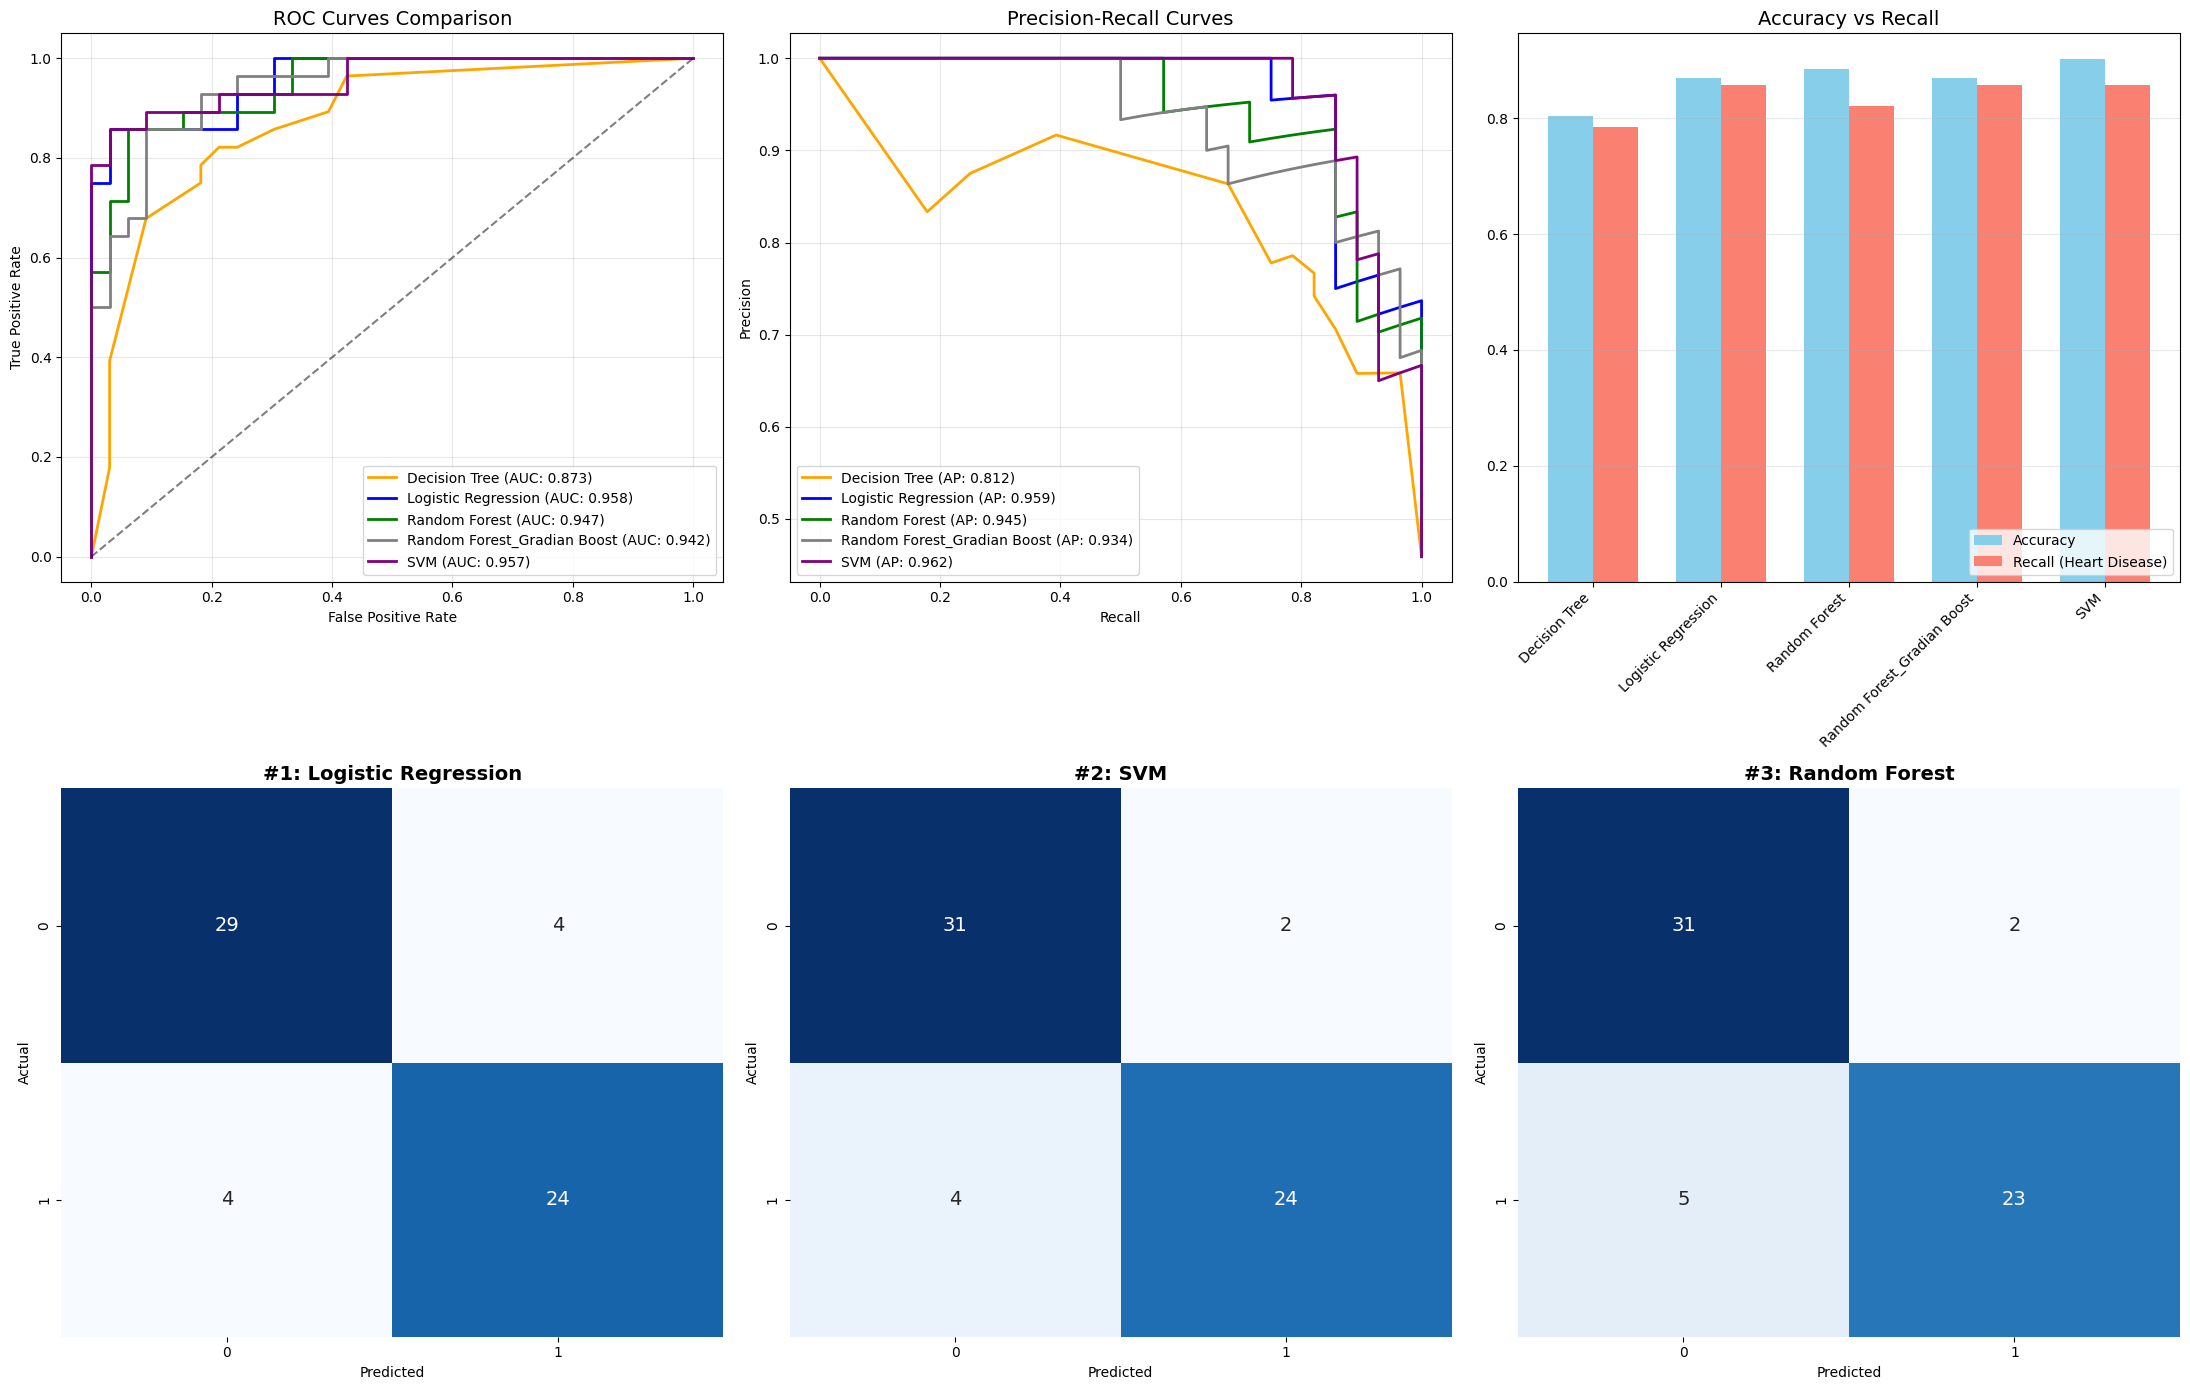

In [7]:
# --- CELL 4: The Ultimate Visualization ---
def plot_final_showdown(results, y_test, metrics_df):
    fig, axes = plt.subplots(2, 3, figsize=(22, 14))
    
    # Custom colors for consistency
    model_colors = {
        'Decision Tree': 'orange', 
        'Logistic Regression': 'blue',
        'Random Forest': 'green', 
        'Gradient Boosting': 'red', 
        'SVM': 'purple'
    }
    
    # Get list of models present
    models = list(results.keys())

    # 1. ROC Curves
    ax = axes[0, 0]
    for name in models:
        y_proba = results[name]['y_proba']
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = metrics_df.loc[name, 'ROC-AUC']
        color = model_colors.get(name, 'gray')
        ax.plot(fpr, tpr, linewidth=2, color=color, label=f'{name} (AUC: {auc:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.set_title('ROC Curves Comparison', fontsize=14)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

    # 2. Precision-Recall Curves
    ax = axes[0, 1]
    for name in models:
        y_proba = results[name]['y_proba']
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        ap = metrics_df.loc[name, 'Avg Precision']
        color = model_colors.get(name, 'gray')
        ax.plot(recall, precision, linewidth=2, color=color, label=f'{name} (AP: {ap:.3f})')
        
    ax.set_title('Precision-Recall Curves', fontsize=14)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend(loc='lower left')
    ax.grid(True, alpha=0.3)

    # 3. Key Metrics Bar Chart (Accuracy vs Recall)
    ax = axes[0, 2]
    x = np.arange(len(models))
    width = 0.35
    
    # Sort models by name to match x-axis
    sorted_models = models # Use order from keys
    accs = [metrics_df.loc[m, 'Accuracy'] for m in sorted_models]
    recs = [metrics_df.loc[m, 'Recall (1)'] for m in sorted_models]
    
    ax.bar(x - width/2, accs, width, label='Accuracy', color='skyblue')
    ax.bar(x + width/2, recs, width, label='Recall (Heart Disease)', color='salmon')
    
    ax.set_title('Accuracy vs Recall', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(sorted_models, rotation=45, ha='right')
    ax.legend(loc='lower right')
    ax.grid(True, axis='y', alpha=0.3)
    
    # 4, 5, 6. Confusion Matrices for Top 3 Models (by ROC)
    top_3_models = metrics_df.index[:3]
    
    for i in range(3):
        ax = axes[1, i]
        if i < len(top_3_models):
            name = top_3_models[i]
            y_pred = results[name]['y_pred']
            cm = confusion_matrix(y_test, y_pred)
            
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                        cbar=False, annot_kws={"size": 14})
            ax.set_title(f'#{i+1}: {name}', fontsize=14, fontweight='bold')
            ax.set_xlabel('Predicted')
            ax.set_ylabel('Actual')
        else:
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# Run visualization
plot_final_showdown(consolidated_results, y_test_truth, df_summary)